In [9]:
import time as timer
t_start = timer.time()

import gc
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
os.environ['NUMBA_NUM_THREADS'] = '32'
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numba import get_num_threads, set_num_threads

from core import (
    compute_and_save_sweep_scan,
    compute_sweep_scan_for_a,
    fit_gamma_from_poles,
    fit_power_law,
    g_iterator_selected_image_rows,
    format_a_for_filename,
    plot_a_gamma_fit,
    plot_decay_fit,
    plot_w0_starting_lines,
    pole_config_for_a as make_pole_config_for_a,
    pole_sensitivity_for_a as make_pole_sensitivity_for_a,
    sweep_scan_filename,
)


In [10]:
# runtime
figure_dir = Path('figures')
figure_dir.mkdir(exist_ok=True)
csv_dir = Path('figure_data')
csv_dir.mkdir(exist_ok=True)
worker_dir = Path('.worker_results')
worker_dir.mkdir(exist_ok=True)

# total_cpus = int(os.environ.get('NUMBA_NUM_THREADS', 32))
n_parallel_a = 16
threads_per_job = 2

# numerical grid
eps = 1e-8

selected_a_values = [0.01, 0.1, 1.0, 10.0]
a_values = np.unique(np.concatenate([np.linspace(0.01, 10.0, 50), selected_a_values]))

def output_w_range(a_lst):
    w0_lst = np.zeros_like(a_lst)
    a_large = a_lst > 0.56
    w0_lst[a_large] = 1.11 + 0.39 * a_lst[a_large]
    w0_lst[~a_large] = 0.2 + 2.0 * a_lst[~a_large]
    return -w0_lst, w0_lst
    
w0_min_by_a, w0_max_by_a = output_w_range(a_values)
n_w0 = 10_000
w0_unit = np.linspace(0.0, 1.0, n_w0)
w0_real_arr_by_a = (
    w0_min_by_a[:, None]
    + (w0_max_by_a - w0_min_by_a)[:, None] * w0_unit[None, :]
)
w0_real_arr = w0_real_arr_by_a[0]  # representative grid for the starting-line plot
w0_imag_values = np.linspace(10.0, 10.1, 25)

# model
m = 0.05
iter_range = 20
n_step = int(iter_range / m) + 1

# stability controls
denom_floor = 1e-16
g_abs_max = 1e16

# pole detection and sweep
low_sensitivity_max_a = 0.5
high_sensitivity_min_a = 3.0
low_a_pole_sensitivity = 0.65
mid_a_pole_sensitivity = 0.15
high_a_pole_sensitivity = 0.0001

plot_log_vmin = -1.3
plot_log_vmax = 0.3

# set_num_threads(total_cpus)
print(f"numba threads in notebook process: {get_num_threads()}")
print(f"n_step: {n_step}")
print(f"sweep scans run {n_parallel_a} a values at a time with {threads_per_job} numba threads each")


numba threads in notebook process: 16
n_step: 401
sweep scans run 16 a values at a time with 2 numba threads each


In [11]:
def pole_sensitivity_for_a(a_value):
    return make_pole_sensitivity_for_a(
        a_value,
        low_sensitivity_max_a,
        high_sensitivity_min_a,
        low_a_pole_sensitivity,
        mid_a_pole_sensitivity,
        high_a_pole_sensitivity,
    )


def pole_config_for_a(a_value):
    return make_pole_config_for_a(
        a_value,
        low_sensitivity_max_a,
        high_sensitivity_min_a,
        low_a_pole_sensitivity,
        mid_a_pole_sensitivity,
        high_a_pole_sensitivity,
    )


print('pole detection sensitivity by a:')
print(f'  a <= {low_sensitivity_max_a:g}: {low_a_pole_sensitivity}')
print(f'  {low_sensitivity_max_a:g} < a < {high_sensitivity_min_a:g}: {mid_a_pole_sensitivity}')
print(f'  a >= {high_sensitivity_min_a:g}: {high_a_pole_sensitivity}')


pole detection sensitivity by a:
  a <= 0.5: 0.65
  0.5 < a < 3: 0.15
  a >= 3: 0.0001


In [12]:
def sweep_gamma_vs_a(a_values):
    gamma_values = np.empty(len(a_values), dtype=np.float64)
    gamma_errors = np.empty(len(a_values), dtype=np.float64)

    with ProcessPoolExecutor(max_workers=n_parallel_a) as executor:
        future_to_idx = {}
        for idx, a_i in enumerate(a_values):
            a_value = float(a_i)
            n_imag = len(w0_imag_values)
            n_real = len(w0_real_arr_by_a[idx])
            scan_w0_arr = (w0_real_arr_by_a[idx][None, :] + 1j * w0_imag_values[:, None]).ravel()
            future = executor.submit(
                compute_and_save_sweep_scan,
                a_value,
                scan_w0_arr,
                pole_config_for_a(a_value),
                eps,
                m,
                n_step,
                denom_floor,
                g_abs_max,
                n_imag,
                n_real,
                worker_dir,
                threads_per_job,
            )
            future_to_idx[future] = idx
            del scan_w0_arr

        for future in as_completed(future_to_idx):
            idx = future_to_idx[future]
            a_value = float(a_values[idx])
            gamma, gamma_err, n_poles, scan_path = future.result()
            gamma_values[idx] = gamma
            gamma_errors[idx] = gamma_err
            print(
                f'a = {a_value:g}: sweep found {n_poles} pole candidates, '
                f'gamma = {gamma:.6f}, saved {scan_path}'
            )
            gc.collect()

    return gamma_values, gamma_errors


def sweep_scan_path(a_value):
    return worker_dir / sweep_scan_filename(a_value)


def load_sweep_scan(a_value, mmap_mode='r'):
    return np.load(sweep_scan_path(a_value), mmap_mode=mmap_mode)


def save_csv(path, header, rows):
    np.savetxt(path, rows, delimiter=',', header=header, comments='')


def save_w0_starting_lines_csv(path, w0_real_arr, w0_imag_values):
    real_grid = np.tile(w0_real_arr, len(w0_imag_values))
    imag_grid = np.repeat(w0_imag_values, len(w0_real_arr))
    save_csv(path, 'omega_real,omega_imag', np.column_stack([real_grid, imag_grid]))


def save_decay_fit_csv(path, time, decay_curves, fit_curve):
    if time is None:
        return
    fit_values = fit_curve if fit_curve is not None else np.full_like(time, np.nan)
    save_csv(path, 'time,decay,fit_decay', np.column_stack([time, decay_curves, fit_values]))


def save_gamma_fit_csv(data_path, fit_path, a_values, gamma_values, gamma_errors, C, x, fit_a):
    save_csv(data_path, 'a,gamma,gamma_err', np.column_stack([a_values, gamma_values, gamma_errors]))
    if np.isfinite(C) and np.isfinite(x) and len(fit_a):
        a_fit = np.linspace(fit_a.min(), fit_a.max(), 500)
        save_csv(fit_path, 'a,gamma_fit', np.column_stack([a_fit, C * a_fit**x]))


def sweep_scan_plot_data(data, xlim=None, ylim=None):
    scan_w0_arr = data['scan_w0_arr']
    scan_log_abs_g = data['scan_log_abs_g']
    m_value = float(data['m'])
    n_step_value = int(data['n_step'])

    real_values = np.asarray(scan_w0_arr.real)
    reset_indices = np.flatnonzero(np.diff(real_values) < 0) # check real value jumps backward
    # the real splitting are the same, so take the first one to determine the grid shape
    n_real = int(reset_indices[0] + 1) if len(reset_indices) else len(scan_w0_arr)
    n_imag = len(scan_w0_arr) // n_real

    w0_grid = scan_w0_arr.reshape(n_imag, n_real)
    value_grid = scan_log_abs_g.reshape(n_imag, n_real, n_step_value)
    x_values = w0_grid[0].real # real part is the same across rows (x-axis grid)
    w0_imag_start_values = w0_grid[:, 0].imag
    # Use the same physical image geometry as pole selection, then draw as cells instead of scatter points.
    z_grid = np.transpose(value_grid, (2, 0, 1)).reshape(n_step_value * n_imag, n_real)
    y_values = (
        w0_imag_start_values[None, :]
        - m_value * np.arange(n_step_value)[:, None]
    ).reshape(n_step_value * n_imag)
    row_step_indices = np.broadcast_to(
        np.arange(n_step_value)[:, None],
        (n_step_value, n_imag),
    ).reshape(n_step_value * n_imag)
    row_imag_indices = np.broadcast_to(
        np.arange(n_imag)[None, :],
        (n_step_value, n_imag),
    ).reshape(n_step_value * n_imag)
    y_order = np.argsort(y_values)
    y_values = y_values[y_order]
    z_grid = z_grid[y_order]
    row_step_indices = row_step_indices[y_order]
    row_imag_indices = row_imag_indices[y_order]

    real_mask = np.ones(n_real, dtype=bool)
    if xlim is not None:
        real_mask = (x_values >= xlim[0]) & (x_values <= xlim[1])
    y_mask = np.ones(len(y_values), dtype=bool)
    if ylim is not None:
        y_mask = (y_values >= ylim[0]) & (y_values <= ylim[1])

    x_values = x_values[real_mask]
    y_values = y_values[y_mask]
    z_grid = z_grid[y_mask][:, real_mask]
    row_step_indices = row_step_indices[y_mask]
    row_imag_indices = row_imag_indices[y_mask]

    return x_values, y_values, z_grid, row_step_indices, row_imag_indices, w0_imag_start_values


def cell_edges(values):
    edges = np.empty(len(values) + 1, dtype=values.dtype)
    edges[1:-1] = 0.5 * (values[:-1] + values[1:])
    edges[0] = values[0] - 0.5 * (values[1] - values[0])
    edges[-1] = values[-1] + 0.5 * (values[-1] - values[-2])
    return edges


def sweep_scan_plot_grid(data, xlim=None, ylim=None):
    x_values, y_values, z_grid, _, _, _ = sweep_scan_plot_data(data, xlim=xlim, ylim=ylim)
    return cell_edges(x_values), cell_edges(y_values), z_grid


def save_heatmap_grid_csv(path, a_value, xlim=None, ylim=None):
    data = load_sweep_scan(a_value)
    x_values, y_values, z_grid, row_step_indices, row_imag_indices, w0_imag_start_values = sweep_scan_plot_data(
        data,
        xlim=xlim,
        ylim=ylim,
    )
    n_step_value = int(data['n_step'])
    m_value = float(data['m'])
    selected_row_lookup = np.full((n_step_value, len(w0_imag_start_values)), -1, dtype=np.int64)
    selected_row_lookup[row_step_indices, row_imag_indices] = np.arange(len(row_step_indices), dtype=np.int64)
    g_grid = g_iterator_selected_image_rows(
        x_values,
        w0_imag_start_values,
        selected_row_lookup,
        len(row_step_indices),
        float(a_value),
        eps,
        m_value,
        n_step_value,
        denom_floor,
        g_abs_max,
    )
    with open(path, 'w') as file:
        file.write('omega_real,omega_imag,log10_abs_g,g_real,g_imag,g_abs\n')
        for row_idx, y_value in enumerate(y_values):
            rows = np.column_stack([
                x_values,
                np.full_like(x_values, y_value),
                z_grid[row_idx],
                g_grid[row_idx].real,
                g_grid[row_idx].imag,
                np.abs(g_grid[row_idx]),
            ])
            np.savetxt(file, rows, delimiter=',')


def save_heatmap_poles_csv(path, a_value, xlim=None, ylim=None):
    data = load_sweep_scan(a_value)
    pole_w = np.asarray(data['pole_w'])
    pole_mask = np.ones(len(pole_w), dtype=bool)
    if xlim is not None:
        pole_mask &= (pole_w.real >= xlim[0]) & (pole_w.real <= xlim[1])
    if ylim is not None:
        pole_mask &= (pole_w.imag >= ylim[0]) & (pole_w.imag <= ylim[1])
    visible_poles = pole_w[pole_mask]
    save_csv(path, 'pole_real,pole_imag', np.column_stack([visible_poles.real, visible_poles.imag]))


def plot_sweep_scan_from_npz(
    a_value,
    xlim=None,
    ylim=None,
    log_vmin=None,
    log_vmax=None,
    save_path=None,
    show=True,
):
    data = load_sweep_scan(a_value)
    x_edges, y_edges, z_grid = sweep_scan_plot_grid(data, xlim=xlim, ylim=ylim)
    pole_w = data['pole_w']

    if log_vmin is None:
        log_vmin = plot_log_vmin if plot_log_vmin is not None else np.nanpercentile(z_grid, 5)
    if log_vmax is None:
        log_vmax = plot_log_vmax if plot_log_vmax is not None else np.nanpercentile(z_grid, 99.8)

    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    heatmap = ax.pcolormesh(
        x_edges,
        y_edges,
        z_grid,
        shading='auto',
        cmap='magma',
        vmin=log_vmin,
        vmax=log_vmax,
        rasterized=True,
    )
    ax.scatter(pole_w.real, pole_w.imag, s=35, facecolors='none', edgecolors='cyan', linewidths=1.2)
    fig.colorbar(heatmap, ax=ax, label=r'$log_{10}(|G|)$')
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel(r'$Re(\omega)$')
    ax.set_ylabel(r'$Im(\omega)$')
    # ax.set_title(f'a = {a_value:g}: Full Saved Sweep Grid')
    if save_path is not None:
        fig.savefig(save_path, format='pdf', bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


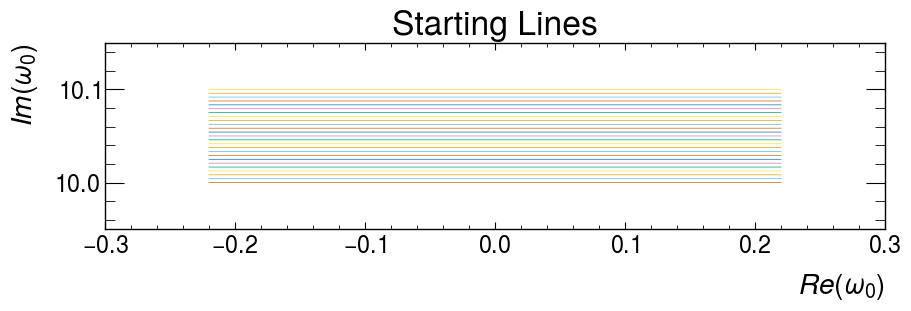

In [13]:
# starting grid
plot_w0_starting_lines(
    w0_real_arr,
    w0_imag_values,
    save_path=figure_dir / 'w0_starting_lines.pdf',
)
save_w0_starting_lines_csv(
    csv_dir / 'w0_starting_lines.csv',
    w0_real_arr,
    w0_imag_values,
)


gamma = 1.188037 +/- 0.029349


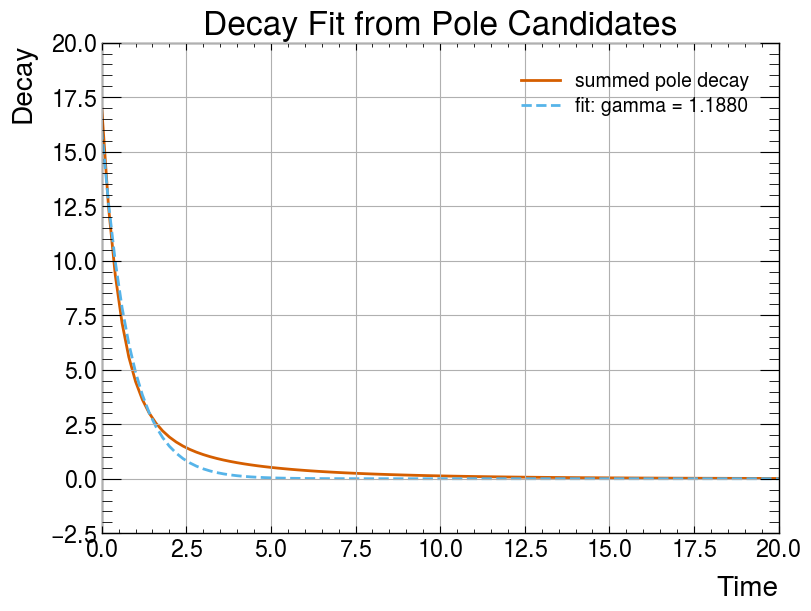

In [14]:
# decay fit for a = 1 using the same log|G| grid used by the sweep
decay_a = 1.0
decay_idx = int(np.flatnonzero(np.isclose(a_values, decay_a))[0])
decay_w0_arr = (
    w0_real_arr_by_a[decay_idx][None, :]
    + 1j * w0_imag_values[:, None]
).ravel()
gamma, gamma_err, n_poles, decay_log_abs_g, decay_pole_w = compute_sweep_scan_for_a(
    decay_a,
    decay_w0_arr,
    pole_config_for_a(decay_a),
    eps,
    m,
    n_step,
    denom_floor,
    g_abs_max,
    len(w0_imag_values),
    len(w0_real_arr_by_a[decay_idx]),
    threads=16,
)
del decay_log_abs_g
gc.collect()
gamma, gamma_err, time, decay_curves, fit_curve = fit_gamma_from_poles(
    decay_pole_w
)
print(f'gamma = {gamma:.6f} +/- {gamma_err:.6f}')
plot_decay_fit(
    gamma,
    time,
    decay_curves,
    fit_curve,
    save_path=figure_dir / f'decay_fit_a_{format_a_for_filename(decay_a)}.pdf',
)
save_decay_fit_csv(
    csv_dir / f'decay_fit_a_{format_a_for_filename(decay_a)}.csv',
    time,
    decay_curves,
    fit_curve,
)


In [ ]:
# sweep a and fit gamma = C * a^x
print(f'sweeping {len(a_values)} a values, {n_parallel_a} at a time with {threads_per_job} numba threads each')
gamma_values, gamma_errors = sweep_gamma_vs_a(a_values)
C, C_err, x, x_err, fit_a, fit_gamma = fit_power_law(a_values, gamma_values, gamma_errors)

if np.isfinite(C) and np.isfinite(x):
    print(f'log-space power-law fit: gamma = {C:.6f} * a^{x:.6f}')
    print(f'C = {C:.6f} +/- {C_err:.6f}')
    print(f'x = {x:.6f}     +/- {x_err:.6f}')
else:
    print('not enough valid gamma values for power-law fit')

plot_a_gamma_fit(
    a_values,
    gamma_values,
    gamma_errors,
    C,
    x,
    fit_a,
    save_path=figure_dir / 'gamma_vs_a_power_law_fit.pdf',
)
save_gamma_fit_csv(
    csv_dir / 'gamma_vs_a_points.csv',
    csv_dir / 'gamma_vs_a_fit_curve.csv',
    a_values,
    gamma_values,
    gamma_errors,
    C,
    x,
    fit_a,
)


sweeping 52 a values, 16 at a time with 2 numba threads each
a = 0.417755: sweep found 41 pole candidates, gamma = 0.893640, saved .worker_results/sweep_scan_a_0p417755.npz
a = 0.1: sweep found 18 pole candidates, gamma = 0.360978, saved .worker_results/sweep_scan_a_0p1.npz
a = 0.213878: sweep found 26 pole candidates, gamma = 0.508737, saved .worker_results/sweep_scan_a_0p213878.npz
a = 0.01: sweep found 6 pole candidates, gamma = 0.194542, saved .worker_results/sweep_scan_a_0p01.npz


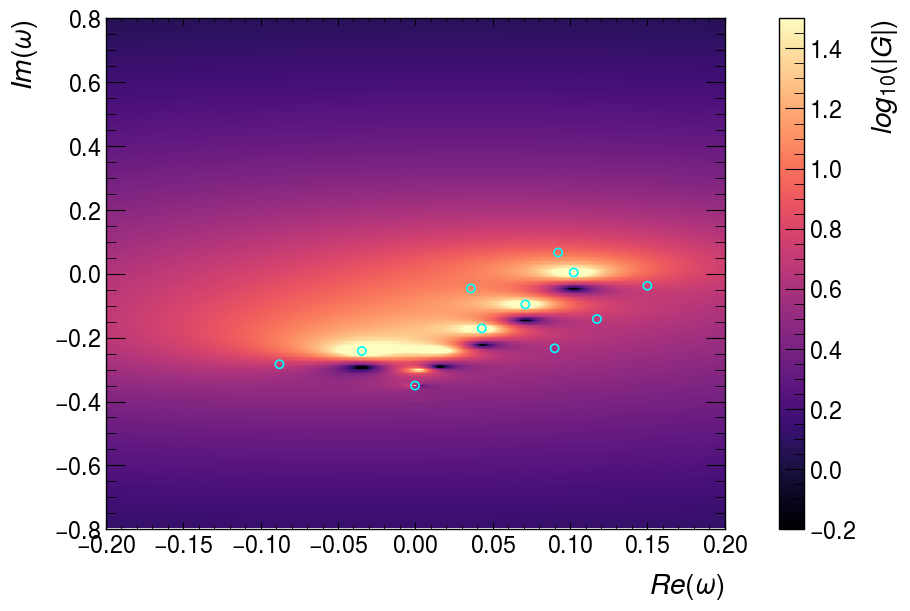

saved figures/sweep_pole_heatmap_a_0p01.pdf


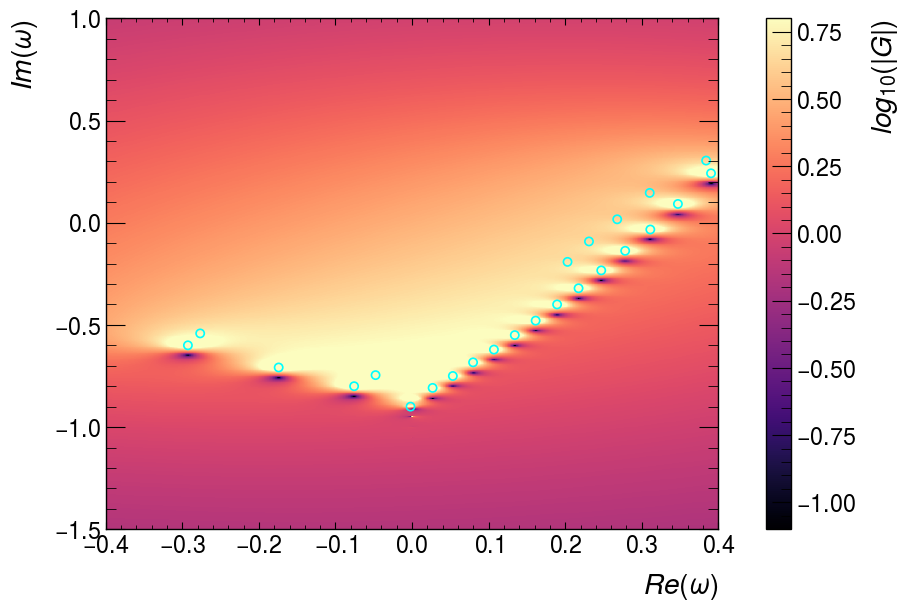

saved figures/sweep_pole_heatmap_a_0p1.pdf


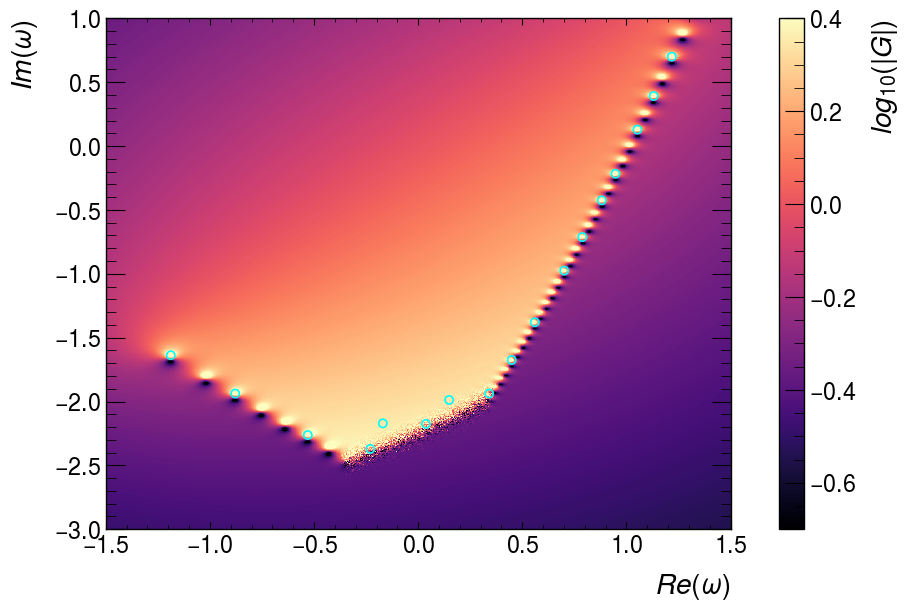

saved figures/sweep_pole_heatmap_a_1.pdf


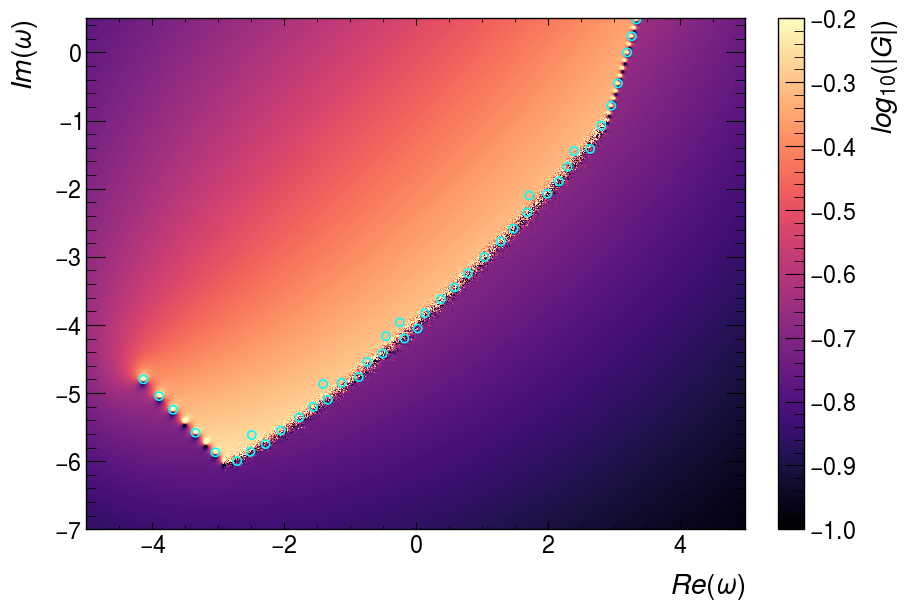

saved figures/sweep_pole_heatmap_a_10.pdf
Total runtime: 160.60 seconds


In [ ]:
import mplhep as hep
plt.style.use(hep.style.ATLAS) # larger and prettier plots for the heatmaps

plot_config_by_a = {
    0.01: {'xlim': (-0.2, 0.2), 'ylim': (-0.8, 0.8), 'log_vmin': -0.2, 'log_vmax': 1.5},
    0.1: {'xlim': (-0.4, 0.4), 'ylim': (-1.5, 1.0), 'log_vmin': -1.1, 'log_vmax': 0.8},
    1.0: {'xlim': (-1.5, 1.5), 'ylim': (-3.0, 1.0), 'log_vmin': -0.7, 'log_vmax': 0.4},
    10.0: {'xlim': (-5.0, 5.0), 'ylim': (-7.0, 0.5), 'log_vmin': -1.0, 'log_vmax': -0.2},
}

for heatmap_a in selected_a_values:
    plot_config = plot_config_by_a.get(heatmap_a, {})
    heatmap_token = format_a_for_filename(heatmap_a)
    save_path = figure_dir / f'sweep_pole_heatmap_a_{format_a_for_filename(heatmap_a)}.pdf'
    plot_sweep_scan_from_npz(
        heatmap_a,
        **plot_config,
        save_path=save_path,
        show=True,
    )
    save_heatmap_grid_csv(
        csv_dir / f'sweep_pole_heatmap_a_{heatmap_token}_grid.csv',
        heatmap_a,
        xlim=plot_config.get('xlim'),
        ylim=plot_config.get('ylim'),
    )
    save_heatmap_poles_csv(
        csv_dir / f'sweep_pole_heatmap_a_{heatmap_token}_poles.csv',
        heatmap_a,
        xlim=plot_config.get('xlim'),
        ylim=plot_config.get('ylim'),
    )
    print(f'saved {save_path}')

t_end = timer.time()
print(f'Total runtime: {t_end - t_start:.2f} seconds')